In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet,LassoCV,RidgeCV,ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
import pickle
%matplotlib inline

In [2]:
df = pd.read_csv('Algerian_forest_fires_cleaned.csv')

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1.0,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2.0,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3.0,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4.0,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5.0,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [4]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [5]:
df.drop(columns = ['day','month','year'], inplace = True)

In [6]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [7]:
df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 0, 1)

In [8]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [9]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [10]:
## Independenta and Dependent Features
X = df.drop(columns = ['FWI'])
y = df['FWI']

In [11]:
# Train test split
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state=42)

In [12]:
xtrain.shape,xtest.shape

((182, 11), (61, 11))

In [13]:
## Feature Selection based on Correlation
xtrain.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


<Axes: >

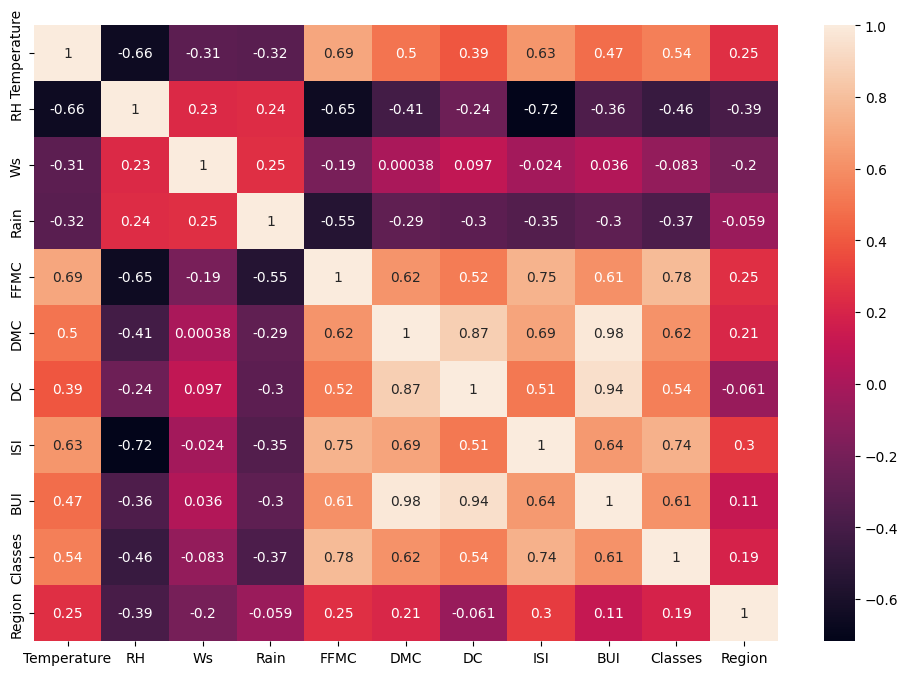

In [14]:
## Check for Multicollinearity
plt.figure(figsize=(12,8))
sns.heatmap(xtrain.corr(), annot=True)

In [15]:
def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            #print(corr_matrix.iloc[i, j])
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [16]:
xtrain.drop(columns = list(correlation(xtrain, 0.85)), inplace=True)
xtest.drop(columns = list(correlation(xtest, 0.85)), inplace=True)

In [17]:
xtrain.shape,xtest.shape

((182, 9), (61, 9))

In [18]:
## Standardization

scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

In [19]:
pickle.dump(scaler, open('scaler.pkl', 'wb'))

Text(0.5, 1.0, 'X_train After Standardization')

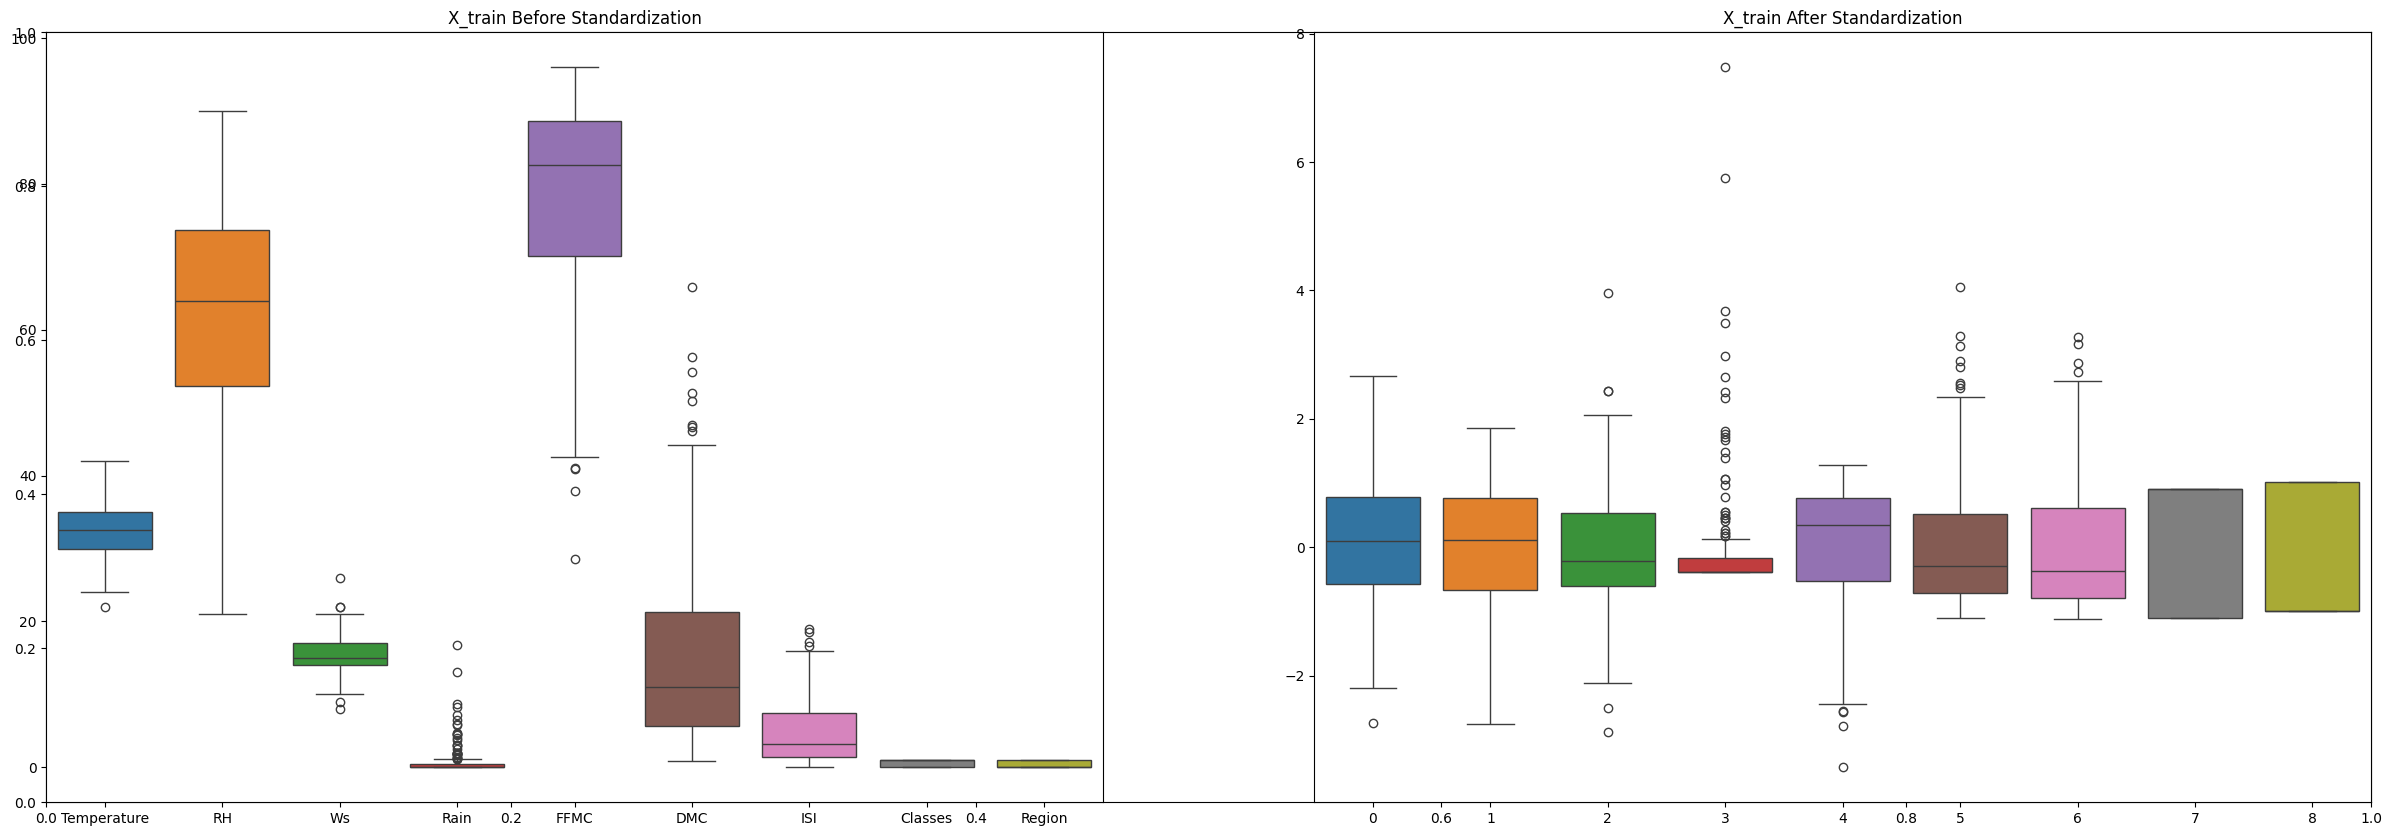

In [20]:
## Box plots to understand effects of Standardization
plt.subplots(figsize = (30,10))
plt.subplot(1,2,1)
sns.boxplot(data = xtrain)
plt.title('X_train Before Standardization')
plt.subplot(1,2,2)
sns.boxplot(data = xtrain_scaled)
plt.title('X_train After Standardization')

# Linear Regression

In [21]:
model = LinearRegression()
model.fit(xtrain_scaled, ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
y_pred = model.predict(xtest_scaled)
mae = mean_absolute_error(ytest, y_pred)
mse = mean_squared_error(ytest, y_pred)
r2_score_value = r2_score(ytest, y_pred)
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}') 
print(f'R2 Score: {r2_score_value}')

Mean Absolute Error: 0.546823646524997
Mean Squared Error: 0.6742766873791582
R2 Score: 0.9847657384266951


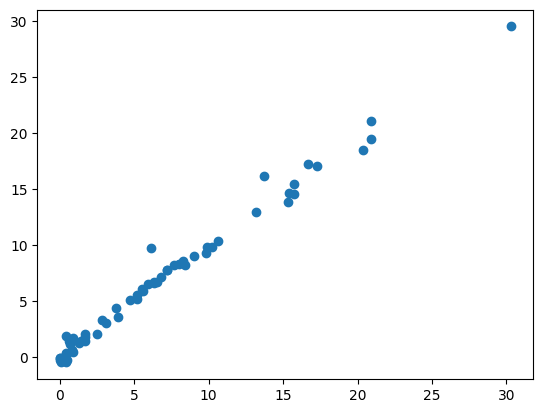

In [23]:
plt.scatter(ytest, y_pred)

In [24]:
pickle.dump(model, open('regression_model.pkl', 'wb'))

# Lasso Regression

In [25]:
model = Lasso()
model.fit(xtrain_scaled, ytrain)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [26]:
y_pred = model.predict(xtest_scaled)
mae = mean_absolute_error(ytest, y_pred)
mse = mean_squared_error(ytest, y_pred)
r2_score_value = r2_score(ytest, y_pred)
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}') 
print(f'R2 Score: {r2_score_value}')

Mean Absolute Error: 1.133175994914409
Mean Squared Error: 2.248345891897477
R2 Score: 0.9492020263112388


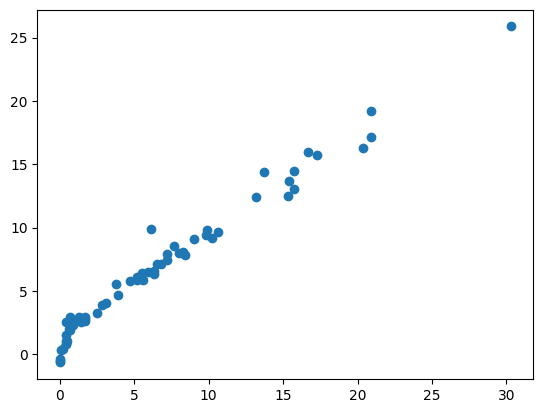

In [27]:
plt.scatter(ytest, y_pred)

In [28]:
model = LassoCV(cv = 5)
model.fit(xtrain_scaled, ytrain)

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


In [29]:
y_pred = model.predict(xtest_scaled)
mae = mean_absolute_error(ytest, y_pred)
mse = mean_squared_error(ytest, y_pred)
r2_score_value = r2_score(ytest, y_pred)
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}') 
print(f'R2 Score: {r2_score_value}')

Mean Absolute Error: 0.6199701158263431
Mean Squared Error: 0.7924995554743625
R2 Score: 0.9820946715928275


In [30]:
print(f'Optimal Alpha: {model.alpha_}')
print(f'Number of Alphas Tried: {len(model.alphas_)}')
print(f"MSE for alpha tried: {len(model.mse_path_)}")

Optimal Alpha: 0.05725391318234408
Number of Alphas Tried: 100
MSE for alpha tried: 100


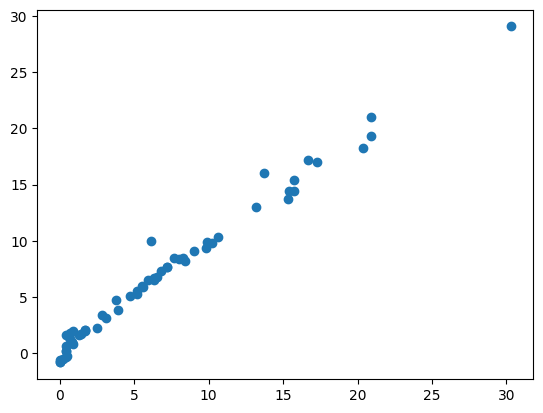

In [31]:
plt.scatter(ytest, y_pred)

# Ridge Regression

In [32]:
model = Ridge()
model.fit(xtrain_scaled, ytrain)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [33]:
y_pred = model.predict(xtest_scaled)
mae = mean_absolute_error(ytest, y_pred)
mse = mean_squared_error(ytest, y_pred)
r2_score_value = r2_score(ytest, y_pred)
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}') 
print(f'R2 Score: {r2_score_value}')

Mean Absolute Error: 0.5642305340105691
Mean Squared Error: 0.6949198918152073
R2 Score: 0.9842993364555513


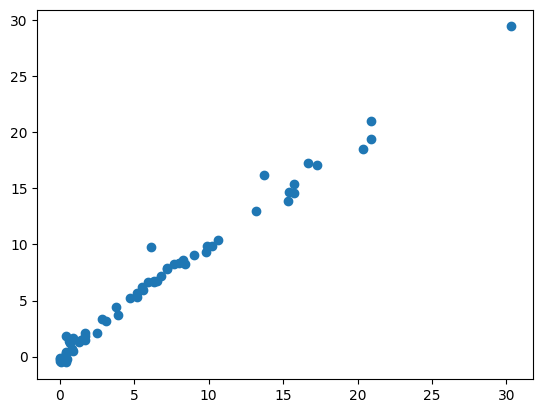

In [34]:
plt.scatter(ytest, y_pred)

In [35]:
model = RidgeCV(cv = 5)
model.fit(xtrain_scaled, ytrain)

,alphas,"(0.1, ...)"
,fit_intercept,True
,scoring,None
,cv,5
,gcv_mode,None
,store_cv_results,False
,alpha_per_target,False


In [36]:
y_pred = model.predict(xtest_scaled)
mae = mean_absolute_error(ytest, y_pred)
mse = mean_squared_error(ytest, y_pred)
r2_score_value = r2_score(ytest, y_pred)
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}') 
print(f'R2 Score: {r2_score_value}')

Mean Absolute Error: 0.5642305340105691
Mean Squared Error: 0.6949198918152073
R2 Score: 0.9842993364555513


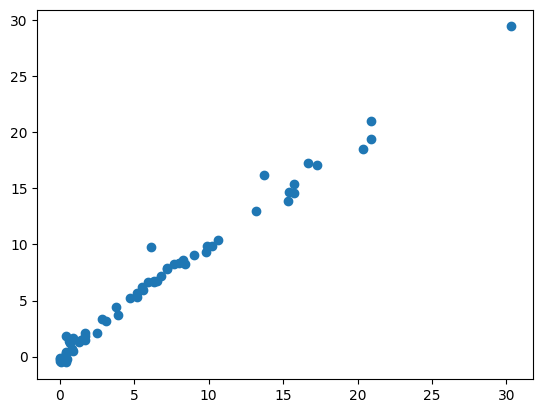

In [37]:
plt.scatter(ytest, y_pred)

In [38]:
model.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': False}

# Elastic Net

In [39]:
model = ElasticNet()
model.fit(xtrain_scaled, ytrain)

,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [40]:
y_pred = model.predict(xtest_scaled)
mae = mean_absolute_error(ytest, y_pred)
mse = mean_squared_error(ytest, y_pred)
r2_score_value = r2_score(ytest, y_pred)
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}') 
print(f'R2 Score: {r2_score_value}')

Mean Absolute Error: 1.8822353634896
Mean Squared Error: 5.517251101025224
R2 Score: 0.8753460589519703


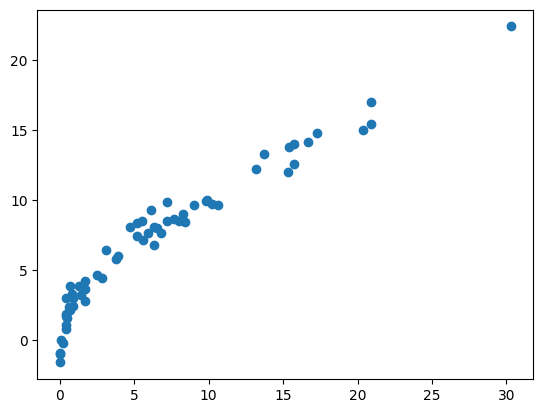

In [41]:
plt.scatter(ytest, y_pred)

In [42]:
model = ElasticNetCV(cv = 5)
model.fit(xtrain_scaled, ytrain)

,l1_ratio,0.5
,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,cv,5
,copy_X,True
,verbose,0


In [43]:
y_pred = model.predict(xtest_scaled)
mae = mean_absolute_error(ytest, y_pred)
mse = mean_squared_error(ytest, y_pred)
r2_score_value = r2_score(ytest, y_pred)
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}') 
print(f'R2 Score: {r2_score_value}')

Mean Absolute Error: 0.6575946731430901
Mean Squared Error: 0.8222830416276264
R2 Score: 0.9814217587854941


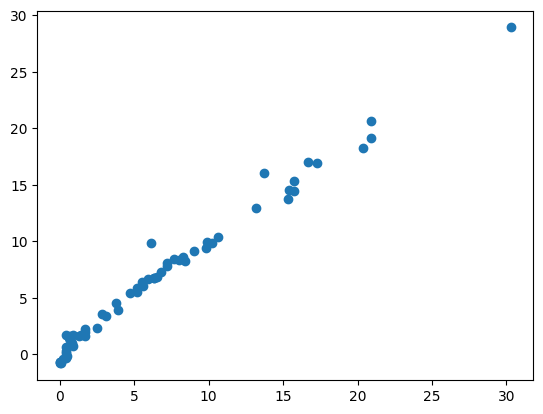

In [44]:
plt.scatter(ytest, y_pred)